In [77]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [78]:
# Task 1. Data Preparation

# Load dataset
df = pd.read_csv('../data/q2_customers.csv')

# display shape and first 5 rows using head
print("Shape:", df.shape)
df.head()

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [79]:
# Scale all features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why scaling is important before K-Means
K-Means uses Euclidean distance calculations to assign points to clusters. If the features are on very different scales (for example, annual_spend in thousands and visits_per_month in double digits), variables with larger numeric ranges, such as `annual_spend` or `basket_size`, can dominate the distance calculation and clustering process and distort the results. StandardScaler transforms all features to the same scale, ensuring each variable contributes fairly to clustering.

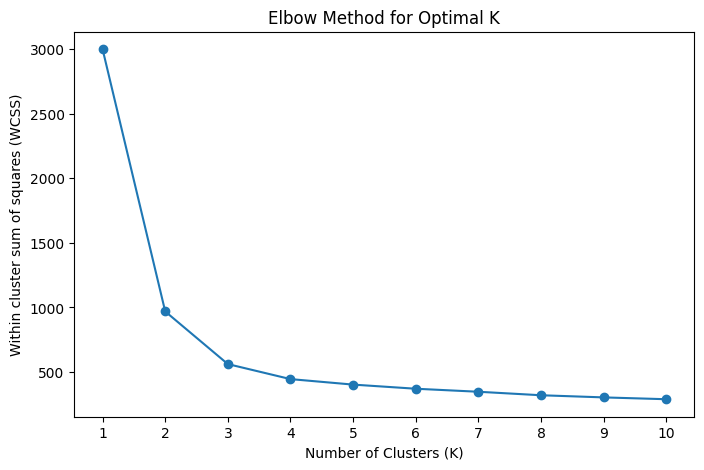

In [80]:
# Task 2. Choosing K — Elbow Method
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within cluster sum of squares (WCSS)")
plt.xticks(range(1,11))
plt.show()

### Choosing the optimal K
The elbow point appears where the reduction in WCSS begins to slow noticeably. The elbow plot shows a sharp drop in WCSS from K=1 to K=4, after which the decrease becomes much smaller. This suggests that based on the curve, K=4 is a reasonable choice for optimal number of clusters because it captures most of the clustering structure without adding unnecessary complexity.

In [81]:
# Task 3. K-Means Clustering

# Fit model with chosen K
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Add cluster column
df['cluster'] = kmeans.fit_predict(scaled_df)

# Show first rows
df.head()

# Cluster centroids (original scale)
centroids_original_df = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                            columns=df.columns[:-1])  # exclude cluster column

centroids_original_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


### Business interpretation of clusters
- **Cluster 0** represents younger, frequent shoppers with low annual spend and small basket sizes. These customers appear highly active but low-value per transaction.
- **Cluster 1** represents older, very high-spending customers who shop infrequently and have not visited recently. These may be valuable but at-risk customers who need reactivation.
- **Cluster 2** represents middle-aged, moderate-spending customers with balanced visit frequency and basket size. This looks like a stable mainstream customer segment.
- **Cluster 3** represents older, high-value customers with large basket sizes and low visit frequency, but they are more recent than Cluster 1. These could be premium shoppers with strong potential for targeted loyalty offers.

In [82]:
# Task 4. Dimensionality Reduction with PCA
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_df)

# Create PCA DataFrame
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']

pca_df.head()

# Explained Variance Ratio
print('Explained Variance Ratio:', pca.explained_variance_ratio_)

# Feature Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### Interpretation of what PC1 and PC2 captures
PC1 appears to capture overall customer value and shopping profile. It loads positively on `annual_spend`, `basket_size`, `num_categories_purchased`, and `age`, while loading negatively on `visits_per_month`, suggesting a contrast between high-value low-frequency shoppers and lower-value frequent shoppers.

PC2 is dominated by `days_since_last_visit`, which means it mainly captures recency. Customers with higher PC2 values tend to have gone longer since their last visit.

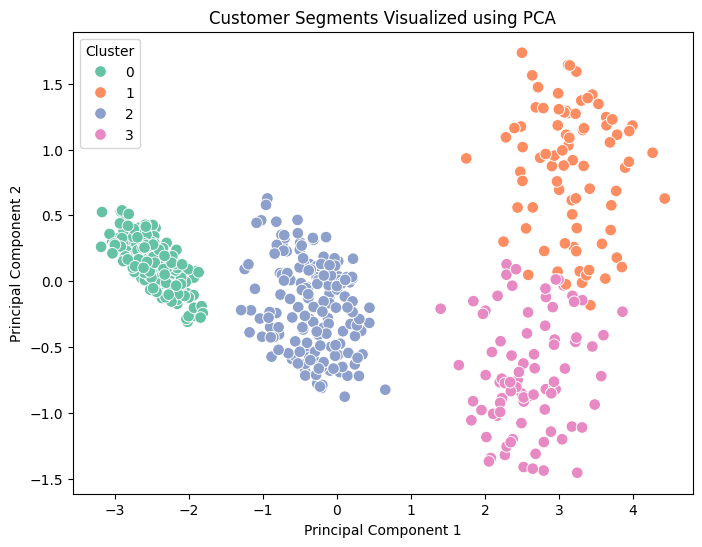

In [83]:
# Task 5. Cluster Visualisation
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2',
    s=70
)

plt.title('Customer Segments Visualized using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()